In [1]:
# loading the Libaries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)
print(type(mnist))
print(mnist.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [3]:
x = mnist.data
y = mnist.target

print(x.shape)
print(y.shape)

(70000, 784)
(70000,)


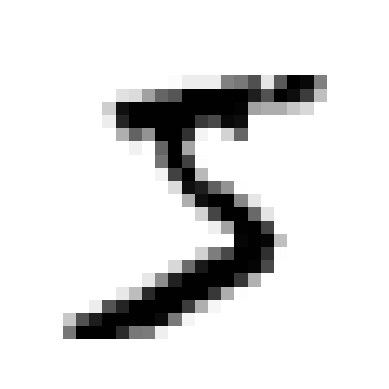

In [4]:
def plot_image(image):
    img = image.reshape(28, 28)
    plt.imshow(img, cmap='binary')
    plt.axis('off')

image = x[0]
plot_image(image)
plt.show()

In [5]:
y[0]

'5'

In [6]:
# training a binary classifier

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, test_size=10000, random_state=42)
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')

from sklearn.linear_model import SGDClassifier
sgd = SGDClassifier()
sgd.fit(x_train, y_train_5)
sgd.predict([x[0]])

array([ True])

In [7]:
# testing Accuracy using cross validation

from sklearn.model_selection import cross_val_score

sgd_val_score = cross_val_score(sgd, x_train, y_train_5, cv=3, scoring='accuracy')
sgd_val_score

array([0.95305, 0.9709 , 0.9659 ])

In [8]:
# testing Accuracy using dummy classifier
# it predicts the most frequent class in a dataset

from sklearn.dummy import DummyClassifier

dc = DummyClassifier()
dc.fit(x_train, y_train_5)
print(any(dc.predict(x_train)))
print()

dc_val_score = cross_val_score(dc, x_train, y_train_5, cv=3, scoring='accuracy')
dc_val_score

False



array([0.90985, 0.9098 , 0.9098 ])

In [9]:
# making a y_train prediction

from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd, x_train, y_train_5, cv=3)
y_train_pred

array([False, False, False, ..., False, False, False], shape=(60000,))

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53511,  1078],
       [ 1518,  3893]])

In [11]:
# precision of the classifier is the accuracy of the positive predictions
# 

from sklearn.metrics import precision_score, recall_score

pred_score = precision_score(y_train_5, y_train_pred)
rec_score = recall_score(y_train_5, y_train_pred)

print('Precision Score:', pred_score)
print('Recall Score:', rec_score)

# Precision Score = 0.82 (≈82%) means: “When the model predicts a digit is 5, it’s correct about 82% of the time.”
#In other words, most of its positive predictions are right, but about 18% are false alarms (it said “5” when it wasn’t).

# Recall Score = 0.66 (≈66%) means: “Out of all the actual 5s in the dataset, the model correctly found about 66% of them.”
# So it misses around one‑third of the true 5s (false negatives).

Precision Score: 0.7831422249044457
Recall Score: 0.7194603585289225


In [12]:
from sklearn.metrics import f1_score

f_score = f1_score(y_train_5, y_train_pred)
print('F1 Score:', f_score)

# F1 score of 0.73 means the classifier is reasonably good, but not excellent
# it’s cautious (good precision) but misses quite a few positives (lower recall). The F1 score captures that balance in one metric.

F1 Score: 0.7499518397225968


In [13]:
# Using decision_function()

y_score = sgd.decision_function([x[0]])
y_score

# a decision score of about 3203.89. which is positive means digit is 5

array([3394.13140176])

In [14]:
# setting my own threshold
threshold=0
y_threshold_set = (y_score>threshold)
y_threshold_set 

array([ True])

In [15]:
threshold = 4000
y_threshold_set = (y_score>threshold)
y_threshold_set 

array([False])

In [16]:
# How to choose a Threshold

# Asking for a model confidence Scope
y_scores = cross_val_predict(sgd, x_train, y_train_5, cv=3, method='decision_function')
y_scores

array([-30197.12959743, -19017.27849371, -23709.58608177, ...,
       -17177.42404564, -14671.04175414,  -5157.15600447], shape=(60000,))

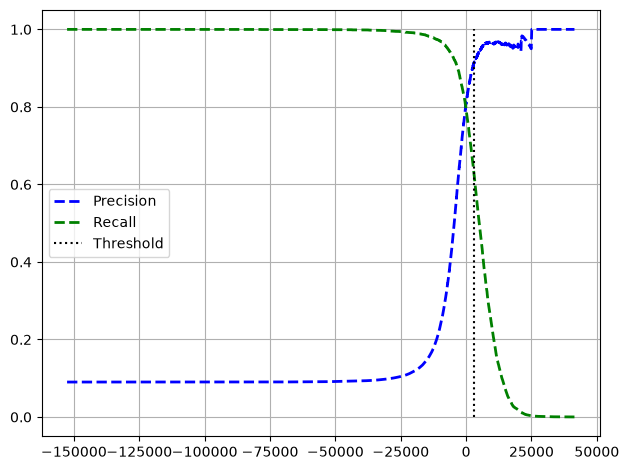

In [17]:
# computing values at different threshold
# he function adds a last precision of 0 and a last recall of 1, corresponding to an infinite threshold

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g--', label='Recall', linewidth=2)
plt.vlines(3000, 0, 1.0, 'k', 'dotted', label='Threshold')

plt.legend(loc="best")
plt.subplots_adjust(right=0.8)   # push plot left, leave space on right

plt.grid()
plt.tight_layout()
plt.show()

In [18]:
# argmax() returns the first index of the maximum value 

ind_90_pred = (precisions >= 0.90).argmax()
threshold_for_90 = thresholds[ind_90_pred]
threshold_for_90

np.float64(2479.074741185814)

In [19]:
y_train_pred_90 = (y_scores >= threshold_for_90)
print(precision_score(y_train_5, y_train_pred_90))
print(recall_score(y_train_5, y_train_pred_90))

0.9
0.6586582886712253


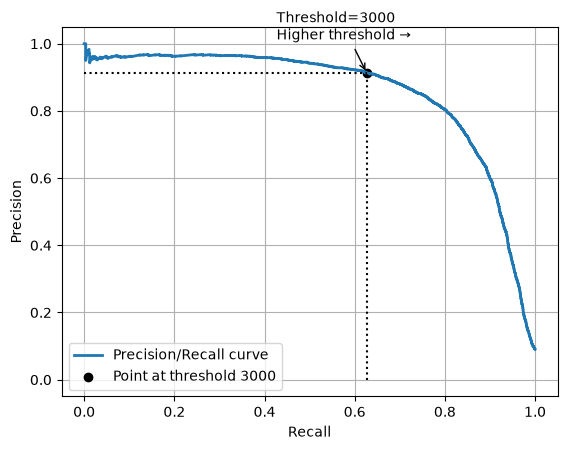

In [20]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Compute precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

# Plot the Precision–Recall curve
plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# --- Step 1: Pick threshold (e.g., 3000) ---
threshold = 3000

# --- Step 2: Find precision & recall at that threshold ---
# Locate the index where threshold is closest to 3000
idx = (thresholds >= threshold).argmax()
prec_at_thresh = precisions[idx]
rec_at_thresh = recalls[idx]

# --- Step 3: Plot the point ---
plt.scatter(rec_at_thresh, prec_at_thresh, color="black", label="Point at threshold 3000")

# --- Step 4: Add helper lines (optional) ---
plt.vlines(rec_at_thresh, 0, prec_at_thresh, colors="k", linestyles="dotted")
plt.hlines(prec_at_thresh, 0, rec_at_thresh, colors="k", linestyles="dotted")

# --- Step 5: Annotate with text (optional) ---
plt.annotate("Threshold=3000\nHigher threshold →",
             xy=(rec_at_thresh, prec_at_thresh),
             xytext=(rec_at_thresh-0.2, prec_at_thresh+0.1),
             arrowprops=dict(arrowstyle="->", color="black"))

# Labels & legend
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.legend(loc="lower left")
plt.show()


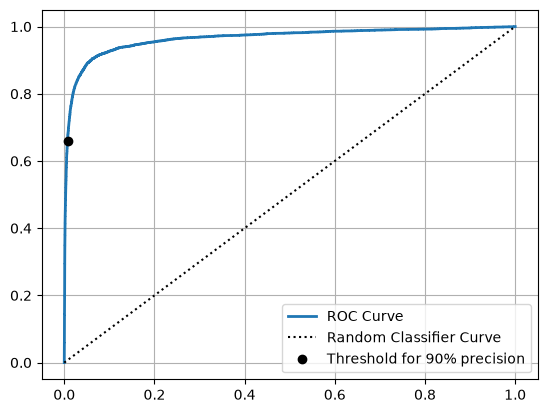

In [21]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

ind_for_threshold_90 = (thresholds <= threshold_for_90).argmax()
fpr_90, tpr_90 = fpr[ind_for_threshold_90], tpr[ind_for_threshold_90]

plt.plot(fpr, tpr, label='ROC Curve', linewidth=2)
plt.plot([0, 1], [0, 1], 'k:', label='Random Classifier Curve')
plt.plot([fpr_90], [tpr_90], 'ko', label='Threshold for 90% precision')

plt.grid()
plt.legend()
plt.show()


In [22]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_train_5, y_scores)
auc_score

# AUC = 0.9641 means your classifier has a 96.41% chance of ranking a random “5” higher than a random “non‑5”.

0.965310405003971

In [23]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(random_state=42)
y_forest_pred = cross_val_predict(forest, x_train, y_train_5, cv=3, method='predict_proba')
y_forest_pred

array([[0.99, 0.01],
       [1.  , 0.  ],
       [1.  , 0.  ],
       ...,
       [1.  , 0.  ],
       [0.87, 0.13],
       [0.84, 0.16]], shape=(60000, 2))

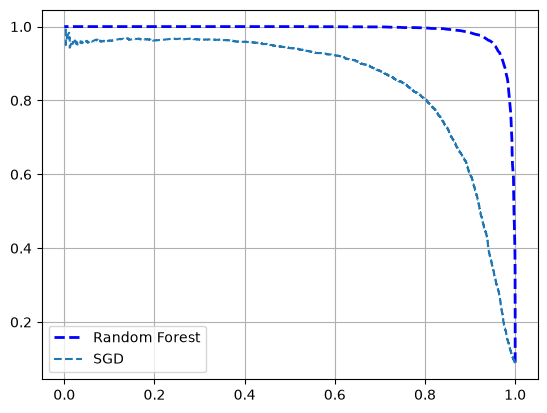

In [24]:
# The second column contains the estimated probabilities for the positive class

y_scores_forest = y_forest_pred[:, 1]
precision_forest, recall_forest, threshold_forest = precision_recall_curve(y_train_5, y_scores_forest)

plt.plot(recall_forest, precision_forest, 'b--', label='Random Forest', linewidth=2)
plt.plot(recalls, precisions, '--', label='SGD')
plt.legend()
plt.grid()
plt.show()

# As you can see in Figure 3-8, the RandomForestClassifier’s PR curve looks much better than the SGDClassifier’s: it comes much closer to the
# top-right corner. Its F score and ROC AUC score are also significantly better

In [25]:
from sklearn.svm import SVC

svc = SVC(random_state=42)
svc.fit(x_train[:2000], y_train[:2000])
svc.predict([x[0]])

# MNIST has exactly 10 classes → digits 0–9.
# SVC is a binary classifier, so Scikit‑Learn automatically applies OvO (One‑Versus‑One) for multiclass tasks.
# OvO requires training: 𝑁(𝑁 − 1)2 classifiers.
# With N = 10, that becomes (10 ×9)/2=45 binary SVMs.
# It cannot magically create more classes than what exists in your y_train.
# It predicts '5' because among the 45 pairwise duels, class 5 wins the most votes.

array(['5'], dtype=object)

In [26]:
some_dig_scores = svc.decision_function([x[0]])
some_dig_scores.round(2)

array([[ 2.79,  0.74,  6.16,  8.29, -0.3 ,  9.29,  3.79,  2.82,  7.18,
         4.06]])

In [27]:
class_ind = some_dig_scores.argmax()
class_ind

np.int64(5)

In [28]:
# Every classifier in Scikit‑Learn stores the list of class labels it was trained on in an attribute called .classes_

print(svc.classes_)
print(svc.classes_[class_ind])

# we use classes_ because argmax returns an index, not the actual label

['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
5


In [29]:
from sklearn.multiclass import OneVsRestClassifier

ovrc = OneVsRestClassifier(SVC(random_state=42))
ovrc.fit(x_train[:2000], y_train[:2000])


,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(random_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[<U1](10,)","['0','1','2',...,'7','8','9']"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[SVC(random_state=42), SVC(random_state=42), SVC(random_state=42), SVC(random_state=42), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,False
n_classes_ n_classes_: intNumber of classes.,int,10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,784
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42


In [30]:
# Each estimator is a separate SVC trained to detect one specific digit.

print(ovrc.predict([x[0]]))
len(ovrc.estimators_)

['5']


10

In [39]:
# SGD 

from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(max_iter=2000, tol=1e-3, random_state=42)

sgd.fit(x_train, y_train)
sgd.predict([x[0]])

array(['3'], dtype='<U1')

In [40]:
sgd.decision_function([x[0]]).round()

array([[-31029., -30763., -11898.,   1446., -23452.,  -1753., -27029.,
        -10209., -11178., -10424.]])

In [41]:
sgd_cross_score = cross_val_score(sgd, x_train, y_train, cv=3, scoring='accuracy')
sgd_cross_score

array([0.8713 , 0.88855, 0.8668 ])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_x = scaler.fit_transform(x_train.astype('float64'))
sgd_cross_score = cross_val_score(sgd, scaled_x, y_train, cv=3, scoring='accuracy')
sgd_cross_score

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict


y_pred = cross_val_predict(sgd, scaled_x, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_pred)
plt.show()

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred, normalize="true", values_format=".0%") 
plt.show()

In [ ]:
sample_weight = (y_train_pred != y_train) 
ConfusionMatrixDisplay.from_predictions(y_train, y_pred, sample_weight=sample_weight, normalize="true", values_format=".0%") 
plt.show()

In [ ]:
import matplotlib.pyplot as plt

def plot_digits(images, title, max_images=25):
    plt.figure(figsize=(5,5))
    plt.suptitle(title, fontsize=14)
    
    # show up to max_images images
    for i in range(min(len(images), max_images)):
        plt.subplot(5, 5, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap="binary")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


# Choose two classes to analyze
cl_a, cl_b = '3', '5'

# Extract the four groups
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]   # True 3 → Pred 3
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]   # True 3 → Pred 5
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]   # True 5 → Pred 3
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]   # True 5 → Pred 5

# Plot all four groups
plot_digits(X_aa, "Correct 3s (True 3 → Pred 3)")
plot_digits(X_ab, "Misclassified 3s (True 3 → Pred 5)")
plot_digits(X_ba, "Misclassified 5s (True 5 → Pred 3)")
plot_digits(X_bb, "Correct 5s (True 5 → Pred 5)")

In [ ]:
from sklearn.neighbors import KNeighborsClassifier 

y_train_large = (y_train >= '7') 
y_train_odd = (y_train.astype('int8') % 2 == 1) 
y_multilabel = np.c_[y_train_large, y_train_odd] 
knn_clf = KNeighborsClassifier() 
knn_clf.fit(X_train, y_multilabel)

In [ ]:
knn_clf.predict([some_digit]) 

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3) 
f1_score(y_multilabel, y_train_knn_pred, average="macro") 

In [ ]:
from sklearn.multioutput import ClassifierChain 
chain_clf = ClassifierChain(SVC(), cv=3, random_state=42) 
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

In [ ]:
chain_clf.predict([some_digit]) 

In [ ]:
np.random.seed(42)  # to make this code example reproducible 
noise = np.random.randint(0, 100, (len(X_train), 784)) 
X_train_mod = X_train + noise 
noise = np.random.randint(0, 100, (len(X_test), 784)) 
X_test_mod = X_test + noise 
y_train_mod = X_train 
y_test_mod = X_test

In [ ]:
knn_clf = KNeighborsClassifier() 
knn_clf.fit(X_train_mod, y_train_mod) 
clean_digit = knn_clf.predict([X_test_mod[0]]) 
plot_digit(clean_digit) 
plt.show()